# Dans ce premier notebook, nous allons télécharger et nettoyer les données

In [22]:
#!pip install lxml
#!pip install html5lib
#!pip install bs4
#!pip install matplotlib
#!pip install seaborn

In [23]:
import os
import tarfile
import urllib.request
import pandas as pd
import numpy as np

# URLs et chemins
TAR_URL = "https://www.phase-trans.msm.cam.ac.uk/map/data/tar/welddb.tar"
DATA_DIR = os.path.join("..", "data")
TAR_PATH = os.path.join(DATA_DIR, "welddb.tar")
DATA_PATH = os.path.join(DATA_DIR, "welddb.data")

# 1. Création du dossier et téléchargement
os.makedirs(DATA_DIR, exist_ok=True)
req = urllib.request.Request(TAR_URL, headers={"User-Agent": "Mozilla/5.0"})

with urllib.request.urlopen(req) as response, open(TAR_PATH, "wb") as f:
    f.write(response.read())

# 2. Extraction du fichier welddb.data
with tarfile.open(TAR_PATH) as tar:
    tar.extract("welddb.data", path=DATA_DIR)

# 3. Chargement dans Pandas (gestion des valeurs manquantes 'N' et '-')
df = pd.read_csv(DATA_PATH, sep=r"\s+", na_values=["N", "-"])

print(f"Dataset chargé avec succès ! Dimensions : {df.shape}")
df.head()

Dataset chargé avec succès ! Dimensions : (1651, 44)


C:\Users\xavie\AppData\Local\Temp\ipykernel_23276\3005086464.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract("welddb.data", path=DATA_DIR)


,0.037,0.30,0.65,0.008,0.012,0,N,N.1,N.2,N.3,...,N.15,N.16,N.17,N.18,N.19,N.20,N.21,N.22,N.23,Evans-Ni/CMn-1990/1991-0Aaw
0,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-28.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
1,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-38.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
2,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
3,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,-48.0,100.0,NaN,NaN,32,28.0,40.0,0.0,0.0,Evans-Ni/CMn-1990/1991-0Bawch
4,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,-44.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Bht


On voit que les différentes features n'ont pas des noms clairs, on va les renommer avec le fichier .info qui accompagne la db

In [24]:
# Dictionnaire ou liste des 44 noms de colonnes explicites
columns_names = [
    ### Composition chimique
    #wt% pourcentages massiques, si nulle, donnée manquante, imputation médiane
    "C_wt",          # Col 1: Carbon (wt%)
    "Si_wt",         # Col 2: Silicon (wt%)
    "Mn_wt",         # Col 3: Manganese (wt%)
    "S_wt",          # Col 4: Sulphur (wt%)
    "P_wt",          # Col 5: Phosphorus (wt%)
    "Ni_wt",         # Col 6: Nickel (wt%)
    "Cr_wt",         # Col 7: Chromium (wt%)
    "Mo_wt",         # Col 8: Molybdenum (wt%)
    "V_wt",          # Col 9: Vanadium (wt%)
    "Cu_wt",         # Col 10: Copper (wt%)
    "Co_wt",         # Col 11: Cobalt (wt%)
    "W_wt",          # Col 12: Tungsten (wt%)
    
    #Elements mineurs (traces), si nulle, on peut dire 0
    "O_ppm",         # Col 13: Oxygen (ppm)
    "Ti_ppm",        # Col 14: Titanium (ppm)
    "N_ppm",         # Col 15: Nitrogen (ppm)
    "Al_ppm",        # Col 16: Aluminium (ppm)
    "B_ppm",         # Col 17: Boron (ppm)
    "Nb_ppm",        # Col 18: Niobium (ppm)
    "Sn_ppm",        # Col 19: Tin (ppm)
    "As_ppm",        # Col 20: Arsenic (ppm)
    "Sb_ppm",        # Col 21: Antimony (ppm)
    
    #Conditions physiques liées à la soudure, imputation médiane
    "Current_A",     # Col 22: Current (A)
    "Voltage_V",     # Col 23: Voltage (V)
    "AC_DC",         # Col 24: AC or DC
    "Polarity",      # Col 25: Electrode positive or negative
    "Heat_input",    # Col 26: Heat input (kJ/mm)
    "Interpass_temp",# Col 27: Interpass temperature (°C)
    "Weld_type",     # Col 28: Type of weld
    
    #Si nul, pas de post traitement, 0 pour temps, température ambiante
    "PWHT_temp",     # Col 29: Post weld heat treatment temp (°C)
    "PWHT_time",     # Col 30: Post weld heat treatment time (h)
    
    #Test de la soudure
    "Yield_strength",# Col 31: Yield strength (MPa)
    "UTS",           # Col 32: Ultimate tensile strength (MPa)
    "Elongation",    # Col 33: Elongation (%)
    "Reduction_area",# Col 34: Reduction of Area (%)
    "Charpy_temp",   # Col 35: Charpy temperature (°C)
    "Charpy_energy", # Col 36: Charpy impact toughness (J)
    "Hardness",      # Col 37: Hardness (kg/mm2)
    
    "FATT_50",       # Col 38: 50% FATT
    "Primary_ferrite",# Col 39: Primary ferrite in microstructure (%)
    "Ferrite_2nd_phase",# Col 40: Ferrite with second phase (%)
    "Acicular_ferrite",# Col 41: Acicular ferrite (%)
    "Martensite",    # Col 42: Martensite (%)
    "Ferrite_carbide",# Col 43: Ferrite with carbide aggregate (%)
    
    #Identifiant, pas pertinent pour le ML
    "Weld_ID"        # Col 44: Weld ID
]

# Attribution des nouveaux noms de colonnes
df.columns = columns_names

# Verification
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   C_wt               1651 non-null   float64
 1   Si_wt              1651 non-null   float64
 2   Mn_wt              1651 non-null   float64
 3   S_wt               1647 non-null   str    
 4   P_wt               1641 non-null   float64
 5   Ni_wt              696 non-null    float64
 6   Cr_wt              784 non-null    float64
 7   Mo_wt              793 non-null    str    
 8   V_wt               928 non-null    str    
 9   Cu_wt              578 non-null    str    
 10  Co_wt              129 non-null    str    
 11  W_wt               75 non-null     str    
 12  O_ppm              1256 non-null   float64
 13  Ti_ppm             935 non-null    str    
 14  N_ppm              1242 non-null   str    
 15  Al_ppm             905 non-null    str    
 16  B_ppm              504 non-null    

On voit qu'il y a pas mal de valeurs manquantes ainsi que des variables nominales, on va maintenant gérer ce problème. Différents traitement sont appliqués car une variable manquant ne signifie pas forcément la même chose en fonction du type de variable (par ex : si un élement mineur à une valeur nulle, on peut considérer qu'il n'a pas été détecté on peut donc remplacer par 0, alors que si le Yield_strengh manque, c'est que les tests n'ont pas été fait (on ne peut pas remplacer par 0))

Commençons par convertir nos données des colonnes 1 à 11 en float

In [25]:
wt_cols = df.columns[0:12]

#On s'apercoit que les données ont des valeurs " < seuil"; on décide de fixer ces valeurs à la moitié du seuil
def clean_inequality_values(series):
    s = series.astype(str).str.strip()
    is_below = s.str.startswith("<")
    values = pd.to_numeric(s.str.replace("<", "", regex=False), errors="coerce")
    return values.where(~is_below, values / 2)

# 1. Nettoyage et conversion explicite des colonnes wt%
for col in wt_cols:
    df[col] = clean_inequality_values(df[col])

df[wt_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   C_wt    1651 non-null   float64
 1   Si_wt   1651 non-null   float64
 2   Mn_wt   1651 non-null   float64
 3   S_wt    1647 non-null   float64
 4   P_wt    1641 non-null   float64
 5   Ni_wt   696 non-null    float64
 6   Cr_wt   784 non-null    float64
 7   Mo_wt   793 non-null    float64
 8   V_wt    928 non-null    float64
 9   Cu_wt   578 non-null    float64
 10  Co_wt   129 non-null    float64
 11  W_wt    75 non-null     float64
dtypes: float64(12)
memory usage: 154.9 KB


On a nos valeurs pour les colonnes 0 à 11.

On traite ensuite le cas des élements présents en traces (ppm), on fait le choix de dire que si la valeur est manquante, l'élément est juste absent, sa valeur est donc de 0

In [26]:
ppm_cols = df.columns[12:21]

for col in ppm_cols:
    # Récupère quelques exemples uniques de valeurs brutes
    sample_vals = df[col].dropna().unique()[:8]
    print(f"--- Colonne {col} ---")
    print(f"Types observés : {df[col].apply(type).unique()}")
    print(f"Exemples de valeurs : {list(sample_vals)}\n")
    

def clean_ppm_value(val):
    if pd.isna(val) or val in ["N", "-", "nan", ""]:
        return 0.0
    val_str = str(val).strip()
    if val_str.startswith("<"):
        try:
            return float(val_str.replace("<", ""))/2
        except ValueError:
            return 0.0
    try:
        return float(val_str)
    except ValueError:
        return 0.0


# Application du nettoyage
for col in ppm_cols:
    df[col] = df[col].apply(clean_ppm_value)

# Vérification finale
print("Types des colonnes PPM :", df[ppm_cols].dtypes.unique())
print("Nombre de NaN restants :", df[ppm_cols].isna().sum().sum())



--- Colonne O_ppm ---
Types observés : [<class 'float'>]
Exemples de valeurs : [np.float64(400.0), np.float64(390.0), np.float64(380.0), np.float64(410.0), np.float64(471.0), np.float64(461.0), np.float64(476.0), np.float64(446.0)]

--- Colonne Ti_ppm ---
Types observés : [<class 'float'> <class 'str'>]
Exemples de valeurs : ['40', '5', '4', '37', '43', '36', '38', '99']

--- Colonne N_ppm ---
Types observés : [<class 'float'> <class 'str'>]
Exemples de valeurs : ['72', '54', '57', '47', '44', '46', '68', '55']

--- Colonne Al_ppm ---
Types observés : [<class 'float'> <class 'str'>]
Exemples de valeurs : ['6', '60', '150', '250', '420', '660', '5', '78']

--- Colonne B_ppm ---
Types observés : [<class 'float'> <class 'str'>]
Exemples de valeurs : ['3', '17', '32', '64', '19', '36', '69', '<5']

--- Colonne Nb_ppm ---
Types observés : [<class 'float'> <class 'str'>]
Exemples de valeurs : ['520', '530', '620', '700', '510', '560', '<5', '5']

--- Colonne Sn_ppm ---
Types observés : [<cla

In [27]:
cols = ["Ni_wt", "Mn_wt", "Cr_wt", "Mo_wt"]
print(df.loc[721, cols])
print(high_cr[cols].describe().loc[["50%", "max"]])

Ni_wt    3.01
Mn_wt    1.02
Cr_wt    9.17
Mo_wt    0.96
Name: 721, dtype: float64
     Ni_wt  Mn_wt  Cr_wt  Mo_wt
50%   0.17  1.005    8.9   1.00
max   3.01  1.630   10.2   1.04


In [28]:
#Après le pré traitement : 

for col in ppm_cols:
    # Récupère quelques exemples uniques de valeurs brutes
    sample_vals = df[col].dropna().unique()[:8]
    print(f"--- Colonne {col} ---")
    print(f"Types observés : {df[col].apply(type).unique()}")
    print(f"Exemples de valeurs : {list(sample_vals)}\n")

--- Colonne O_ppm ---
Types observés : [<class 'float'>]
Exemples de valeurs : [np.float64(0.0), np.float64(400.0), np.float64(390.0), np.float64(380.0), np.float64(410.0), np.float64(471.0), np.float64(461.0), np.float64(476.0)]

--- Colonne Ti_ppm ---
Types observés : [<class 'float'>]
Exemples de valeurs : [np.float64(0.0), np.float64(40.0), np.float64(5.0), np.float64(4.0), np.float64(37.0), np.float64(43.0), np.float64(36.0), np.float64(38.0)]

--- Colonne N_ppm ---
Types observés : [<class 'float'>]
Exemples de valeurs : [np.float64(0.0), np.float64(72.0), np.float64(54.0), np.float64(57.0), np.float64(47.0), np.float64(44.0), np.float64(46.0), np.float64(68.0)]

--- Colonne Al_ppm ---
Types observés : [<class 'float'>]
Exemples de valeurs : [np.float64(0.0), np.float64(6.0), np.float64(60.0), np.float64(150.0), np.float64(250.0), np.float64(420.0), np.float64(660.0), np.float64(5.0)]

--- Colonne B_ppm ---
Types observés : [<class 'float'>]
Exemples de valeurs : [np.float64(0.0)

In [29]:
df[ppm_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   O_ppm   1651 non-null   float64
 1   Ti_ppm  1651 non-null   float64
 2   N_ppm   1651 non-null   float64
 3   Al_ppm  1651 non-null   float64
 4   B_ppm   1651 non-null   float64
 5   Nb_ppm  1651 non-null   float64
 6   Sn_ppm  1651 non-null   float64
 7   As_ppm  1651 non-null   float64
 8   Sb_ppm  1651 non-null   float64
dtypes: float64(9)
memory usage: 116.2 KB


On a maintenant traiter le cas des éléments traces. On va mainteant s'intéresser aux colonnes 22 à 30.
Ces colonnes contiennnent les conditions physiques de la soudure (température, voltage, type de courant, post traitements ou pas...)
Pour voir comment faire analysons dans un premier temps nos données

In [30]:
proc_cols = df.columns[21:30]

for col in proc_cols:
    sample_vals = df[col].dropna().unique()[:6]
    print(f"--- {col} ---")
    print(f"Type : {df[col].apply(type).unique()}")
    print(f"Exemples : {list(sample_vals)}\n")

--- Current_A ---
Type : [<class 'float'>]
Exemples : [np.float64(170.0), np.float64(180.0), np.float64(165.0), np.float64(280.0), np.float64(285.0), np.float64(680.0)]

--- Voltage_V ---
Type : [<class 'float'>]
Exemples : [np.float64(21.0), np.float64(34.0), np.float64(24.0), np.float64(25.0), np.float64(23.0), np.float64(30.0)]

--- AC_DC ---
Type : [<class 'str'> <class 'float'>]
Exemples : ['DC', 'AC']

--- Polarity ---
Type : [<class 'str'> <class 'float'>]
Exemples : ['+', '0']

--- Heat_input ---
Type : [<class 'float'>]
Exemples : [np.float64(1.0), np.float64(2.0), np.float64(2.1), np.float64(1.8), np.float64(2.8), np.float64(2.9)]

--- Interpass_temp ---
Type : [<class 'str'>]
Exemples : ['200', '150', '175', '107', '100', '250']

--- Weld_type ---
Type : [<class 'str'>]
Exemples : ['MMA', 'ShMA', 'FCA', 'SA', 'TSA', 'SAA']

--- PWHT_temp ---
Type : [<class 'float'>]
Exemples : [np.float64(0.0), np.float64(580.0), np.float64(250.0), np.float64(750.0), np.float64(500.0), np.fl

On voit que nos données sont de différents types. Pour Current_A, Voltage_V, Heat_Input, PWHT_temp et PWHT_time; les données sont déjà sous forme de float. On impute Current_A, Voltage_A, Heat_Input et l'interpass_temp par la médiane. Une valeur manquante pour le post traitement est remplacée par 0 (pas de post traitement). Pour les variables catégorielles (AC_DC, polarity, Weld_type) nous faisons une nouvelle catégorie "Unknown". Nous ajouterons des variables dummies si nécéssaire par la suite.

In [31]:
cat_cols = ["AC_DC", "Polarity", "Weld_type"]

for col in cat_cols:
    # 1. Remplace les vrais NaN / None par 'Unknown'
    df[col] = df[col].fillna("Unknown")

    # 2. Nettoie le texte et remplace les résidus 'nan', 'N', '-'
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(["nan", "N", "-", "", "None"], "Unknown")

df["Interpass_temp"] = pd.to_numeric(
    df["Interpass_temp"].astype(str).str.replace("<", "").str.strip(), 
    errors="coerce"
)

df["PWHT_temp"] = df["PWHT_temp"].fillna(0.0)
df["PWHT_time"] = df["PWHT_time"].fillna(0.0)

# Harmonisation des procédés de soudage
df["Weld_type"] = df["Weld_type"].replace({"ShMA": "MMA", "SMA": "SA"})

# Vérification
for col in cat_cols:
    print(f"Valeurs uniques finales dans {col} : {df[col].unique().tolist()}")
    
df[proc_cols].info()

Valeurs uniques finales dans AC_DC : ['DC', 'AC', 'Unknown']
Valeurs uniques finales dans Polarity : ['+', '0', 'Unknown']
Valeurs uniques finales dans Weld_type : ['MMA', 'FCA', 'SA', 'TSA', 'SAA', 'GTAA', 'GMAA', 'NGSAW', 'NGGMA']
<class 'pandas.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Current_A       1403 non-null   float64
 1   Voltage_V       1403 non-null   float64
 2   AC_DC           1651 non-null   str    
 3   Polarity        1651 non-null   str    
 4   Heat_input      1651 non-null   float64
 5   Interpass_temp  1613 non-null   float64
 6   Weld_type       1651 non-null   str    
 7   PWHT_temp       1651 non-null   float64
 8   PWHT_time       1651 non-null   float64
dtypes: float64(6), str(3)
memory usage: 116.2 KB


Nous passons à la prochaine catégorie de variable, les propriétés mécaniques de la soudure. Nous allons analyser dans un premier temps les données que l'on a. 
Ces variables sont des variables clés car ce sont elles qui permetteront d'évaluer la qualité d'une soudure. De ce fait, on ne peut pas ni pas les imputées, ni les enlevées, on crée un trop gros biais dans nos données dans le cas contraire. On filtrera également les variables cibles avec trop de valeurs manquantes (Hardness, FAT 50, ...)

In [32]:
mech_cols = df.columns[30:38]

for col in mech_cols:
    # Détection des valeurs non directement numériques
    non_num = df[col][
        pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna()
    ].unique()

    nan_count = df[col].isna().sum()
    
    print(f"--- {col} ---")
    print(f"Type actuel : {df[col].dtype}")
    print(f"NaN : {nan_count}")
    print(f"Valeurs non numériques : {list(non_num)}")
    print(
        f"Exemples : {list(df[col].dropna().unique()[:4])}\n"
    )
    

--- Yield_strength ---
Type actuel : float64
NaN : 872
Valeurs non numériques : []
Exemples : [np.float64(370.0), np.float64(413.0), np.float64(402.0), np.float64(468.0)]

--- UTS ---
Type actuel : float64
NaN : 914
Valeurs non numériques : []
Exemples : [np.float64(456.0), np.float64(498.0), np.float64(490.0), np.float64(551.0)]

--- Elongation ---
Type actuel : float64
NaN : 952
Valeurs non numériques : []
Exemples : [np.float64(35.2), np.float64(31.2), np.float64(31.0), np.float64(29.4)]

--- Reduction_area ---
Type actuel : float64
NaN : 947
Valeurs non numériques : []
Exemples : [np.float64(80.6), np.float64(78.7), np.float64(78.8), np.float64(76.8)]

--- Charpy_temp ---
Type actuel : float64
NaN : 772
Valeurs non numériques : []
Exemples : [np.float64(-28.0), np.float64(-38.0), np.float64(-48.0), np.float64(-44.0)]

--- Charpy_energy ---
Type actuel : float64
NaN : 772
Valeurs non numériques : []
Exemples : [np.float64(100.0), np.float64(28.0), np.float64(50.0), np.float64(9.0)]


In [33]:
print("Nombre d'échantillons valides par propriété mécanique :")
print(df[mech_cols].notna().sum())

Nombre d'échantillons valides par propriété mécanique :
Yield_strength    779
UTS               737
Elongation        699
Reduction_area    704
Charpy_temp       879
Charpy_energy     879
Hardness          138
FATT_50            31
dtype: int64


Nous traitons les dernières colonnes maintenant, elles constituent des données un peu "niche" (chères à produire et beaucoup de valeurs manquantes)

In [34]:
micro_cols = df.columns[38:44]

for col in micro_cols:
    nan_count = df[col].isna().sum()
    pct_missing = (nan_count / len(df)) * 100
    
    print(f"--- {col} ---")
    print(f"Type actuel : {df[col].dtype}")
    print(f"NaN : {nan_count} ({pct_missing:.1f}%)")
    print(f"Exemples : {list(df[col].dropna().unique()[:4])}\n")

--- Primary_ferrite ---
Type actuel : str
NaN : 1553 (94.1%)
Exemples : ['32', '13', '19', '8']

--- Ferrite_2nd_phase ---
Type actuel : float64
NaN : 1561 (94.5%)
Exemples : [np.float64(28.0), np.float64(17.0), np.float64(43.0), np.float64(24.0)]

--- Acicular_ferrite ---
Type actuel : float64
NaN : 1561 (94.5%)
Exemples : [np.float64(40.0), np.float64(60.0), np.float64(38.0), np.float64(68.0)]

--- Martensite ---
Type actuel : float64
NaN : 1562 (94.6%)
Exemples : [np.float64(0.0), np.float64(30.0)]

--- Ferrite_carbide ---
Type actuel : float64
NaN : 1562 (94.6%)
Exemples : [np.float64(0.0), np.float64(8.0), np.float64(4.0), np.float64(5.0)]

--- Weld_ID ---
Type actuel : str
NaN : 0 (0.0%)
Exemples : ['Evans-Ni/CMn-1990/1991-0Aawch', 'Evans-Ni/CMn-1990/1991-0Aht', 'Evans-Ni/CMn-1990/1991-0Baw', 'Evans-Ni/CMn-1990/1991-0Bawch']



Vu le nombre de NaN, nous décidons juste de supprimer les données car pas assez représentatives sur notre échantillon, la dernière colonne est juste un identifiant et est inutile pour faire du machine learning.

In [35]:
df = df.drop(columns=micro_cols)
df = df.drop(columns=["Hardness", "FATT_50"])

print(f"Nouvelles dimensions du dataset : {df.shape}")

Nouvelles dimensions du dataset : (1651, 36)


On va maintenant séparer notre dataset pour la validation et les tests. Nous imputerons les données manquantes sur les valeurs d'entrainement uniquement

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["AC_DC", "Polarity", "Weld_type"]

# Inputs: les lignes jusqu'à PWHT_time
feature_cols = list(df.columns[: df.columns.get_loc("PWHT_time") + 1])

# Targets : Charpy_temp est complémentaire à Chapy_energy, on ne prend que l'un des deux
target_cols = ["Yield_strength", "UTS", "Elongation", "Reduction_area", "Charpy_energy"]

# On force nos données en valeurs numériques
num_features = [c for c in feature_cols if c not in cat_cols] + ["Charpy_temp"]
df[num_features] = df[num_features].apply(pd.to_numeric, errors="coerce")
df[target_cols] = df[target_cols].apply(pd.to_numeric, errors="coerce")


def make_preprocessor(num_cols):
    """Unfitted preprocessor: the median is learned on the training data only."""
    return ColumnTransformer(
        [            
            ("num", SimpleImputer(strategy="median", keep_empty_features=True), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ]
    ).set_output(transform="pandas")


datasets = {}
for target in target_cols:
    feats = feature_cols + (["Charpy_temp"] if target == "Charpy_energy" else [])

    valid_mask = df[target].notna()
    X_target = df.loc[valid_mask, feats]
    y_target = df.loc[valid_mask, target]

    # On sépare en training et testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_target, y_target, test_size=0.2, random_state=42
    )

    num_cols = [c for c in feats if c not in cat_cols]
    datasets[target] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "preprocessor": make_preprocessor(num_cols),
    }

    print(f"Target '{target}' -> Train: {X_train.shape} | Test: {X_test.shape}")

Target 'Yield_strength' -> Train: (623, 30) | Test: (156, 30)
Target 'UTS' -> Train: (589, 30) | Test: (148, 30)
Target 'Elongation' -> Train: (559, 30) | Test: (140, 30)
Target 'Reduction_area' -> Train: (563, 30) | Test: (141, 30)
Target 'Charpy_energy' -> Train: (703, 31) | Test: (176, 31)


Nous avons maintenant, pour chaque cible, un jeu d'entraînement et un jeu de test séparés **avant** toute imputation par la médiane.
Les colonnes 1 à 30 (jusqu'à `PWHT_time`) sont les entrées, et les cibles sont `Yield_strength`, `UTS`, `Elongation`, `Reduction_area` et `Charpy_energy` (avec `Charpy_temp` en entrée supplémentaire pour cette dernière).

Par la suite, on cherchera à réduire la dimension de nos données grâce à une ACP (dans un Pipeline, après imputation et standardisation).

Mais avant ça, visualisons un peu nos données (sur le train brut, les NaN sont ignorés par les histogrammes).

X_train (Yield_strength) shape after encoding: (623, 39)


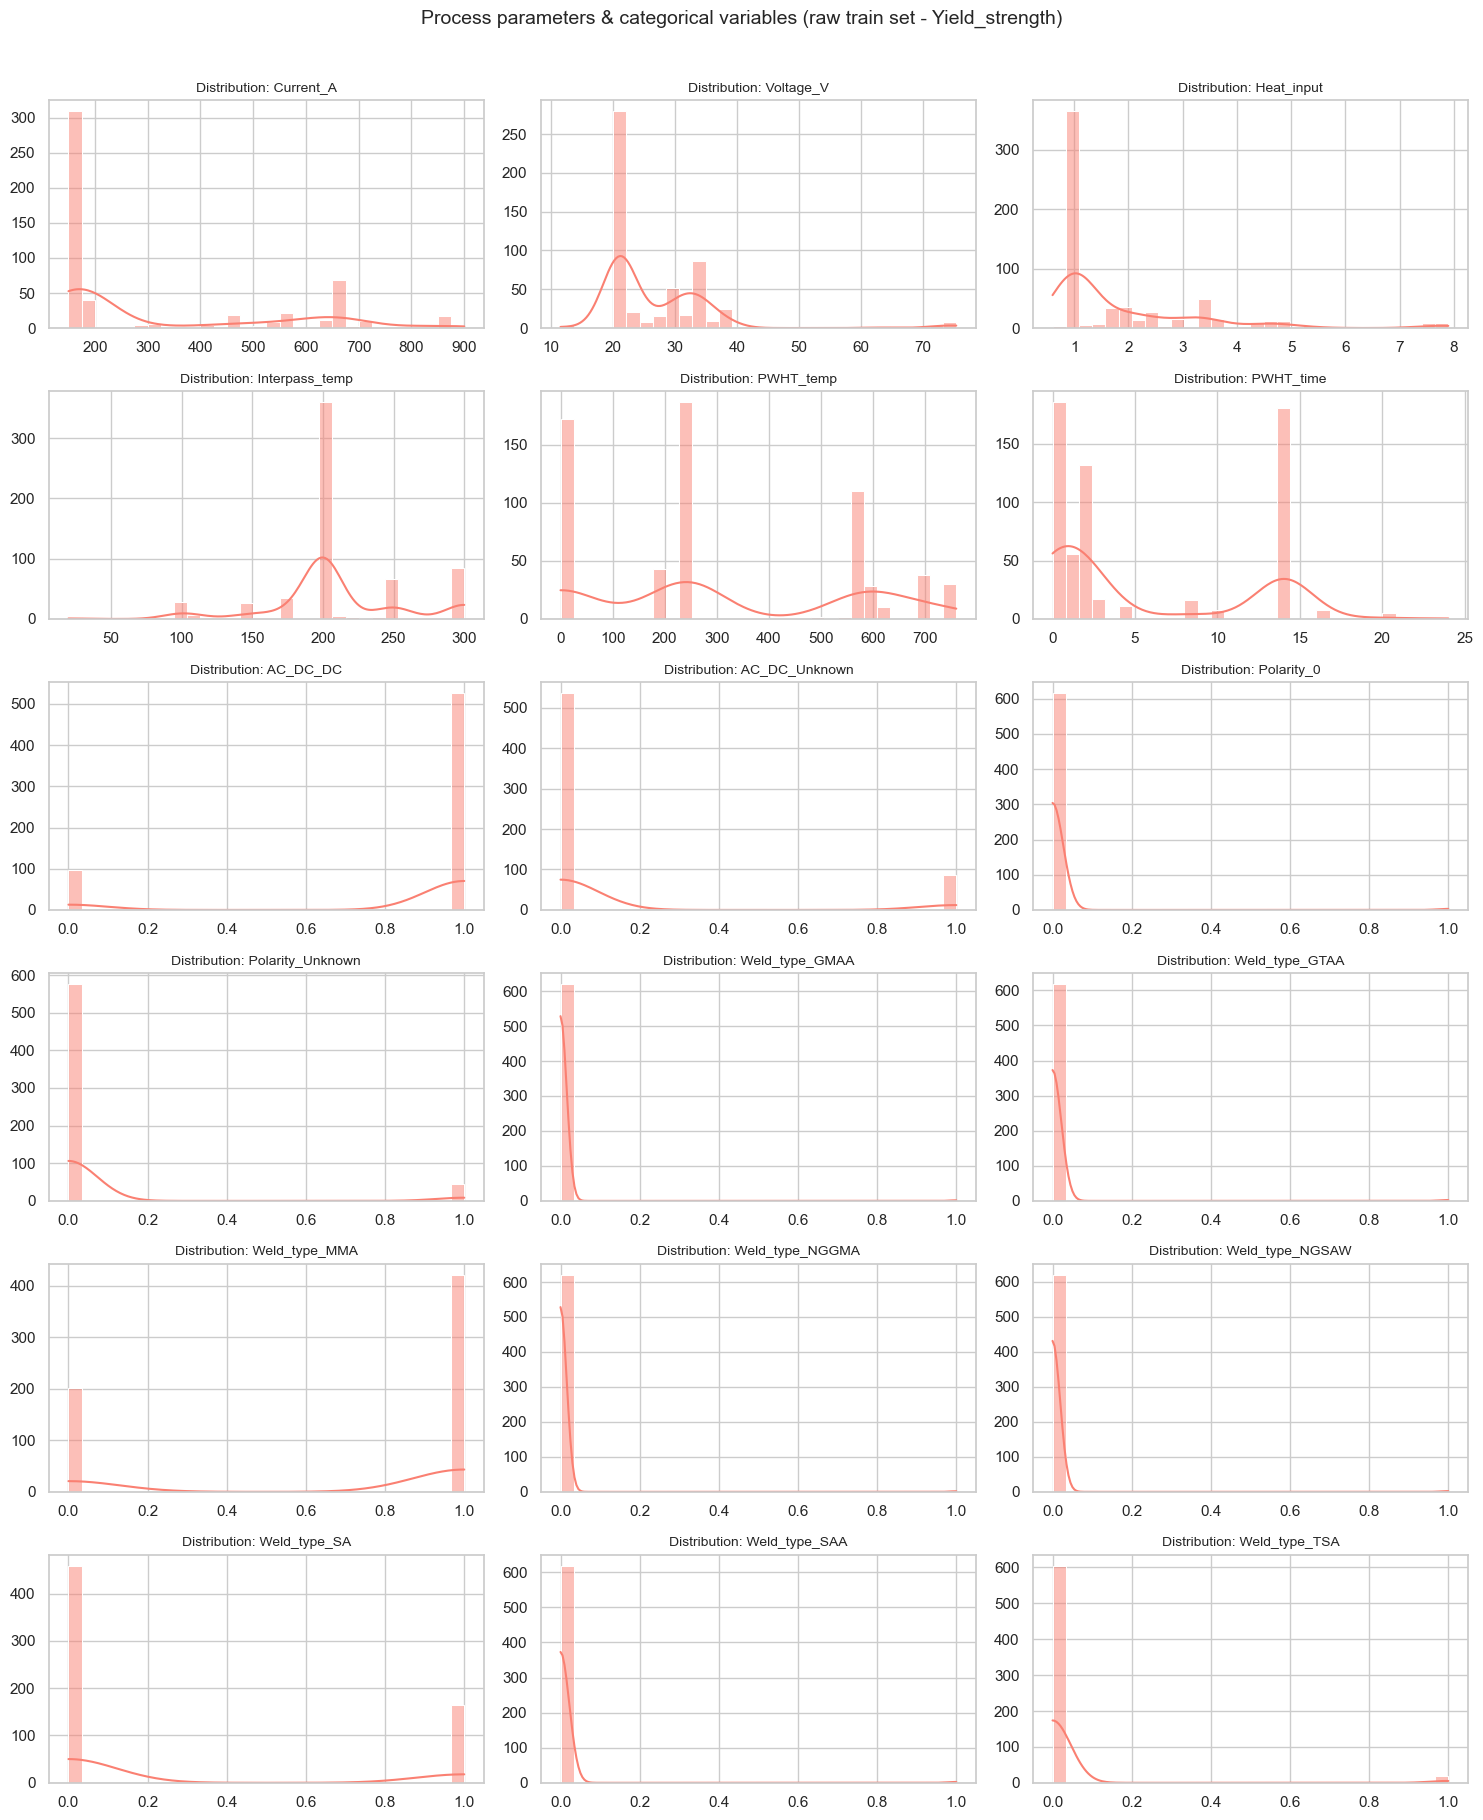

In [37]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

target_ref = "Yield_strength"
X_train_raw = datasets[target_ref]["X_train"]

X_encoded = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True, dtype=float)
print(f"X_train ({target_ref}) shape after encoding: {X_encoded.shape}")

chem_cols = [col for col in X_encoded.columns if "_wt" in col or "_ppm" in col]
proc_and_cat_cols = [col for col in X_encoded.columns if col not in chem_cols]

ncols = 3
nrows = math.ceil(len(proc_and_cat_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows))
axes = axes.flatten()

for i, col in enumerate(proc_and_cat_cols):
    sns.histplot(X_encoded[col].dropna(), kde=True, ax=axes[i], color="salmon", bins=30)
    axes[i].set_title(f"Distribution: {col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(proc_and_cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    f"Process parameters & categorical variables (raw train set - {target_ref})",
    fontsize=14,
    y=1.01,
)
plt.tight_layout()
plt.show()

 A analyser 

 Nous exportons notre base de données triés et commencerons son analyse dans le 2ème notebook 

In [38]:
import os
import pandas as pd

#On exporte différentes données à analyser ensuite
PROCESSED_DIR = os.path.join("..", "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 2. 1 fichier CSV par target avec les features associés
for target, data in datasets.items():
    df_train = data["X_train"].copy()
    df_train[target] = data["y_train"]
    df_train["split"] = "train"

    df_test = data["X_test"].copy()
    df_test[target] = data["y_test"]
    df_test["split"] = "test"

    df_target = pd.concat([df_train, df_test], axis=0)

    csv_path = os.path.join(PROCESSED_DIR, f"welddb_split_{target.lower()}.csv")
    df_target.to_csv(csv_path, index=False)

    print(f"Target '{target}' exported ({df_target.shape[0]} rows, {df_target.shape[1]} cols) -> {csv_path}")

Target 'Yield_strength' exported (779 rows, 32 cols) -> ..\data\processed\welddb_split_yield_strength.csv
Target 'UTS' exported (737 rows, 32 cols) -> ..\data\processed\welddb_split_uts.csv
Target 'Elongation' exported (699 rows, 32 cols) -> ..\data\processed\welddb_split_elongation.csv
Target 'Reduction_area' exported (704 rows, 32 cols) -> ..\data\processed\welddb_split_reduction_area.csv
Target 'Charpy_energy' exported (879 rows, 33 cols) -> ..\data\processed\welddb_split_charpy_energy.csv
